# Patch-Clamp Pipeline Tutorial

This notebook walks through the full pipeline end-to-end using **synthetic data**, so it runs without any real recordings. The three stages are:

1. **`load_data`** &mdash; raw `int16` `.bin` files &rarr; nanoamps (`.npz`)
2. **`baseline_filter`** &mdash; TDS baseline correction + Butterworth low-pass filter (`.npz`)
3. **`chunk_data`** &mdash; split into equal chunks &rarr; final HDF5 (`.h5`)

Requirements: `numpy`, `scipy`, `h5py`, `matplotlib`.

In [1]:
import numpy as np
import h5py
import matplotlib.pyplot as plt

from make_synthetic_data import make_synthetic_recording
from load_data import load_data_nA, save_loaded_data, FSAMPLE
from baseline_filter import baseline_correct, lowpass_filter, process as baseline_process
from chunk_data import save_chunks_hdf5
from pipeline import run_pipeline

print('Sampling rate:', FSAMPLE, 'Hz')

Sampling rate: 25000 Hz


## 0. Generate a synthetic recording

This writes a `.param` file and a `*_Chan_01_*.bin` file in the same binary format the real hardware produces. The synthetic current contains a slow baseline drift, two square "events", and white noise.

In [2]:
info = make_synthetic_recording('demo_data', channel_num=1, duration_s=2.0, n_files=1, seed=42)
print('Wrote synthetic recording to:', info['out_dir'])
print('Samples:', info['n_samples'], '| gain (MOhm):', info['gain_Mohm'])

Wrote synthetic recording to: demo_data
Samples: 50000 | gain (MOhm): 500.0


## 1. Load and convert to nanoamps

`load_data_nA` reads the binary file, parses the `.param` file for the offsets/gain/hold, and converts raw ADC counts to nA.

[load_data] Saved → demo_data/chan01_raw.npz


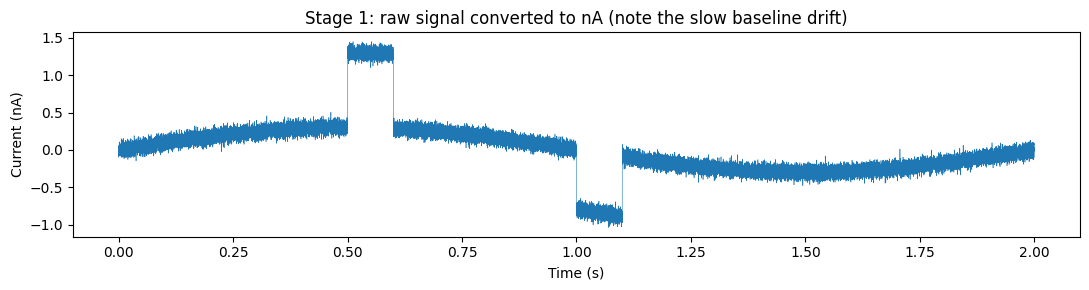

In [3]:
raw = load_data_nA(channel_num=1, data_dir='demo_data')
save_loaded_data(raw, 'demo_data/chan01_raw.npz')

t = raw['t']
data_nA = raw['data_nA']

plt.figure(figsize=(11, 3))
plt.plot(t, data_nA, lw=0.4)
plt.xlabel('Time (s)'); plt.ylabel('Current (nA)')
plt.title('Stage 1: raw signal converted to nA (note the slow baseline drift)')
plt.tight_layout(); plt.show()

## 2. Baseline correction and filtering

We can call the building blocks directly to visualise each step. `baseline_correct` uses the tridiagonal smoother (TDS) to estimate the slow baseline; `lowpass_filter` applies a zero-phase 4th-order Butterworth filter.

`Rsqrd` controls how stiff the estimated baseline is &mdash; smaller values give a smoother (stiffer) baseline.

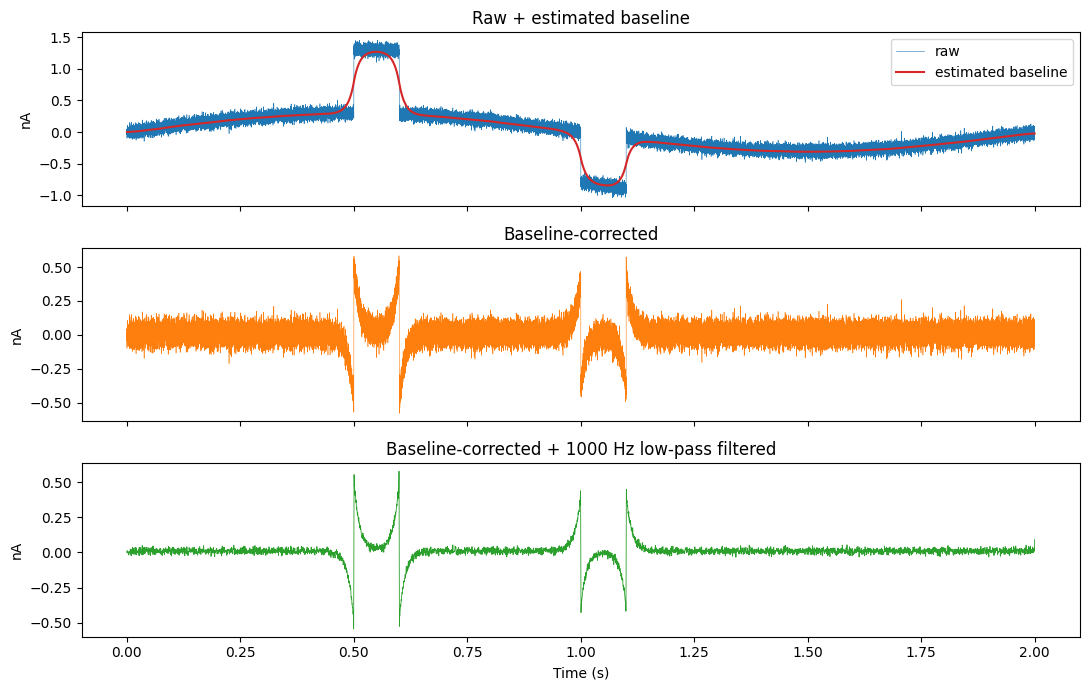

In [4]:
Rsqrd = 1e-5
fcutoff_hz = 1000

corrected, baseline = baseline_correct(data_nA, Rsqrd=Rsqrd)
filtered = lowpass_filter(corrected, fcutoff=fcutoff_hz, fsample=FSAMPLE)

fig, ax = plt.subplots(3, 1, figsize=(11, 7), sharex=True)
ax[0].plot(t, data_nA, lw=0.4, label='raw')
ax[0].plot(t, baseline, lw=1.5, color='C3', label='estimated baseline')
ax[0].legend(loc='upper right'); ax[0].set_ylabel('nA'); ax[0].set_title('Raw + estimated baseline')

ax[1].plot(t, corrected, lw=0.4, color='C1')
ax[1].set_ylabel('nA'); ax[1].set_title('Baseline-corrected')

ax[2].plot(t, filtered, lw=0.6, color='C2')
ax[2].set_ylabel('nA'); ax[2].set_xlabel('Time (s)')
ax[2].set_title(f'Baseline-corrected + {fcutoff_hz} Hz low-pass filtered')
plt.tight_layout(); plt.show()

The two square events are now clearly visible against a flat, near-zero baseline. In a script you would normally use the `process()` wrapper, which does both steps and saves the intermediate `.npz` files for you:

In [5]:
result = baseline_process(
    'demo_data/chan01_raw.npz',
    Rsqrd=Rsqrd,
    fcutoff_hz=fcutoff_hz,
)
print('Saved baseline + filtered .npz intermediates.')

[baseline_filter] Baseline-corrected → demo_data/chan01_raw_baseline.npz
[baseline_filter] Filtered           → demo_data/chan01_raw_baseline_filt_1000Hz.npz
Saved baseline + filtered .npz intermediates.


## 3. Chunk and save as HDF5

The final product splits the filtered signal into equal-length chunks and writes them to an HDF5 file with metadata.

In [6]:
h5_path = save_chunks_hdf5(
    'demo_data/chan01_raw_baseline_filt_1000Hz.npz',
    bias_str='0mV',
    num_chunks=5,
)
print('Final HDF5:', h5_path)

[chunk_data] HDF5 saved → demo_data/chan01_raw_baseline_filt_1000Hz_bias_0mV_5chunks.h5  (5 chunks)
Final HDF5: demo_data/chan01_raw_baseline_filt_1000Hz_bias_0mV_5chunks.h5


Metadata:
  Rsqrd: 1e-05
  bias_str: 0mV
  fcutoff_hz: 1000.0
  fsample: 25000.0
  num_chunks: 5

Chunks: ['chunk_00', 'chunk_01', 'chunk_02', 'chunk_03', 'chunk_04']


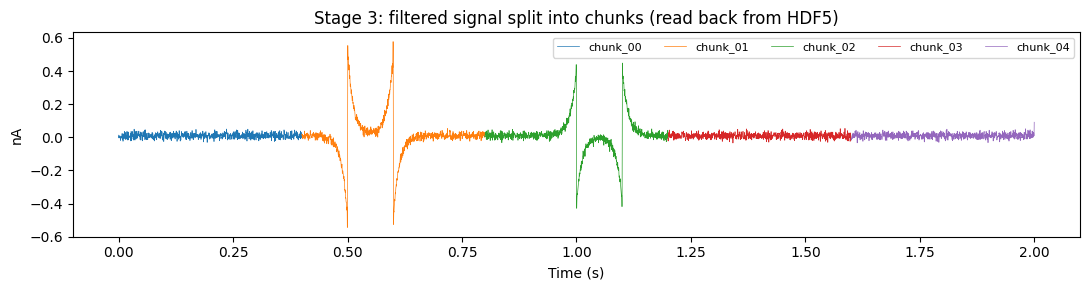

In [7]:
# Inspect the HDF5 contents
with h5py.File(h5_path, 'r') as hf:
    print('Metadata:')
    for k, v in hf['metadata'].attrs.items():
        print(f'  {k}: {v}')
    print('\nChunks:', list(hf['chunks'].keys()))

    fig, ax = plt.subplots(figsize=(11, 3))
    for name in hf['chunks']:
        ax.plot(hf['time'][name][:], hf['chunks'][name][:], lw=0.5, label=name)
    ax.set_xlabel('Time (s)'); ax.set_ylabel('nA')
    ax.set_title('Stage 3: filtered signal split into chunks (read back from HDF5)')
    ax.legend(ncol=5, fontsize=8)
    plt.tight_layout(); plt.show()

## One-shot: the whole pipeline in a single call

Everything above is wrapped by `run_pipeline`, which runs all three stages and writes every artefact to `out_dir`.

In [8]:
artefacts = run_pipeline(
    channel_num=1,
    data_dir='demo_data',
    Rsqrd=1e-5,
    fcutoff_hz=1000,
    bias_str='0mV',
    num_chunks=5,
    out_dir='demo_output',
)
artefacts


=== Step 1: Loading raw data ===
[load_data] Saved → demo_output/chan01_raw.npz

=== Step 2: Baseline correction and filtering ===


[baseline_filter] Baseline-corrected → demo_output/chan01_baseline.npz
[baseline_filter] Filtered           → demo_output/chan01_baseline_filt_1000Hz.npz

=== Step 3: Chunking and saving HDF5 ===
[chunk_data] HDF5 saved → demo_output/chan01_bias_0mV_5chunks.h5  (5 chunks)

=== Pipeline complete ===
  raw_npz        : demo_output/chan01_raw.npz
  baseline_npz   : demo_output/chan01_baseline.npz
  filtered_npz   : demo_output/chan01_baseline_filt_1000Hz.npz
  hdf5           : demo_output/chan01_bias_0mV_5chunks.h5


{'raw_npz': 'demo_output/chan01_raw.npz',
 'baseline_npz': 'demo_output/chan01_baseline.npz',
 'filtered_npz': 'demo_output/chan01_baseline_filt_1000Hz.npz',
 'hdf5': 'demo_output/chan01_bias_0mV_5chunks.h5'}